# Task-1
### Sample and characterise all five

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [81]:
# Create one random number generator
rng = np.random.default_rng(0)

In [82]:
# Uniform distribution
u = rng.uniform(0, 10, 10_000)

# Normal distribution
n = rng.normal(50, 10, 10_000)

# Binomial distribution
b = rng.binomial(20, 0.3, 10_000)

# Poisson distribution
p = rng.poisson(4, 10_000)

# Exponential distribution
e = rng.exponential(2, 10_000)

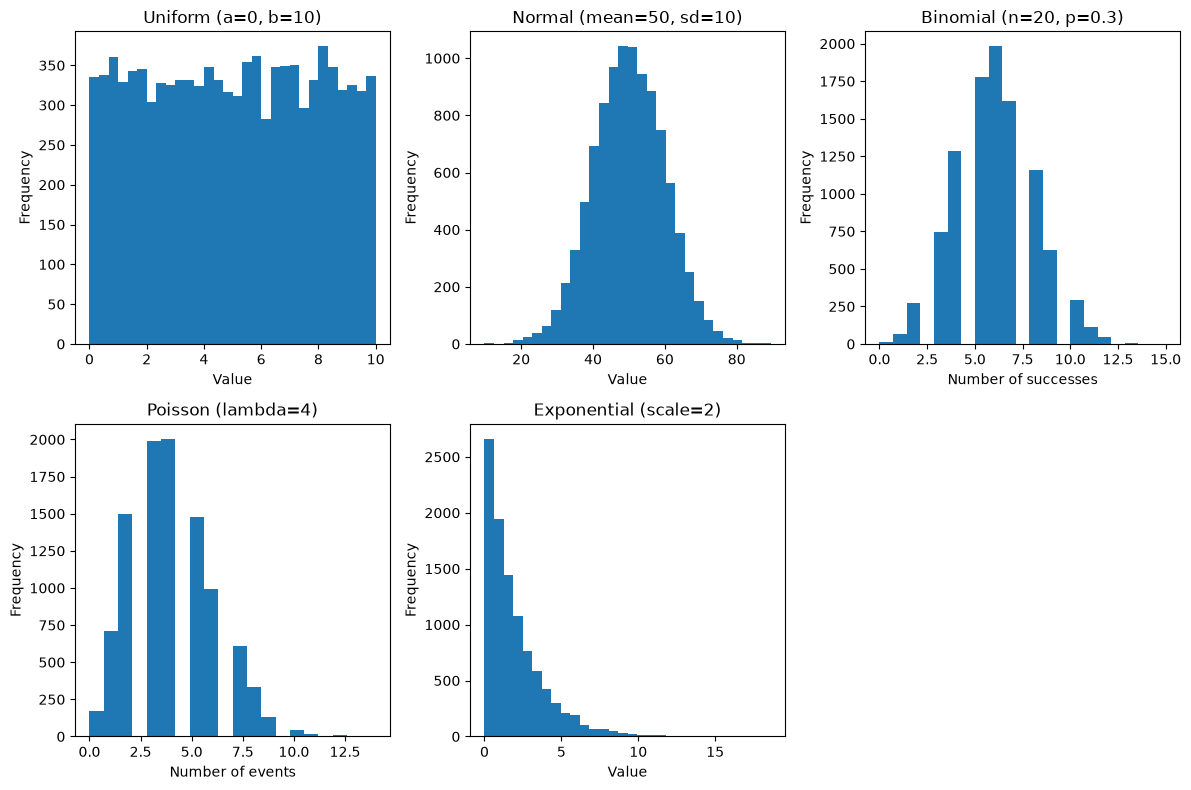

In [83]:
plt.figure(figsize=(12, 8))

# Uniform
plt.subplot(2, 3, 1)
plt.hist(u, bins=30)
plt.title("Uniform (a=0, b=10)")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Normal
plt.subplot(2, 3, 2)
plt.hist(n, bins=30)
plt.title("Normal (mean=50, sd=10)")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Binomial
plt.subplot(2, 3, 3)
plt.hist(b, bins=21)
plt.title("Binomial (n=20, p=0.3)")
plt.xlabel("Number of successes")
plt.ylabel("Frequency")

# Poisson
plt.subplot(2, 3, 4)
plt.hist(p, bins=20)
plt.title("Poisson (lambda=4)")
plt.xlabel("Number of events")
plt.ylabel("Frequency")

# Exponential
plt.subplot(2, 3, 5)
plt.hist(e, bins=30)
plt.title("Exponential (scale=2)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [84]:
print("Uniform")
print("Sample mean:", u.mean())
print("Sample variance:", u.var())
print("Theoretical mean:", (0 + 10) / 2)
print("Theoretical variance:", (10 - 0) ** 2 / 12)

print("\nNormal")
print("Sample mean:", n.mean())
print("Sample variance:", n.var())
print("Theoretical mean:", 50)
print("Theoretical variance:", 10 ** 2)

print("\nBinomial")
print("Sample mean:", b.mean())
print("Sample variance:", b.var())
print("Theoretical mean:", 20 * 0.3)
print("Theoretical variance:", 20 * 0.3 * (1 - 0.3))

print("\nPoisson")
print("Sample mean:", p.mean())
print("Sample variance:", p.var())
print("Theoretical mean:", 4)
print("Theoretical variance:", 4)

print("\nExponential")
print("Sample mean:", e.mean())
print("Sample variance:", e.var())
print("Theoretical mean:", 2)
print("Theoretical variance:", 2 ** 2)

Uniform
Sample mean: 4.9941066006080845
Sample variance: 8.35501524888129
Theoretical mean: 5.0
Theoretical variance: 8.333333333333334

Normal
Sample mean: 50.04451753225605
Sample variance: 98.51393559626398
Theoretical mean: 50
Theoretical variance: 100

Binomial
Sample mean: 5.9804
Sample variance: 4.15141584
Theoretical mean: 6.0
Theoretical variance: 4.199999999999999

Poisson
Sample mean: 3.994
Sample variance: 3.9929639999999997
Theoretical mean: 4
Theoretical variance: 4

Exponential
Sample mean: 1.983883101484185
Sample variance: 3.8951043535588514
Theoretical mean: 2
Theoretical variance: 4


In [85]:
print("Poisson sample mean:", p.mean())
print("Poisson sample variance:", p.var())

print("Difference:", abs(p.mean() - p.var()))

Poisson sample mean: 3.994
Poisson sample variance: 3.9929639999999997
Difference: 0.001036000000000481


In [86]:
#Uniform:Models a quantity where every value within a fixed range has an equal chance, such as a random number between 0 and 10.

#Normal:Models measurements that naturally cluster around an average, such as people's heights or measurement errors.

#Binomial:Models the number of successes in a fixed number of independent trials, such as the number of successful answers out of 20 questions.

#Poisson:Models the number of events occurring in a fixed period or space, such as the number of customers arriving at a shop in one hour.

#Exponential:Models the waiting time until the next event, such as the time until the next customer arrives.

# Task-2 
### The 68-95-99.7 rule

In [87]:
# Mean and standard deviation
mu = 50
sigma = 10

# Generate 100,000 samples
samples = rng.normal(mu, sigma, 100_000)

print("Mean:", samples.mean())
print("Standard deviation:", samples.std())

Mean: 50.00134835429124
Standard deviation: 10.029512212541565


In [88]:
# Values within 1, 2, and 3 standard deviations
within1 = np.mean(np.abs(samples - mu) < sigma)
within2 = np.mean(np.abs(samples - mu) < 2 * sigma)
within3 = np.mean(np.abs(samples - mu) < 3 * sigma)

print("Within 1 SD:", within1)
print("Within 2 SD:", within2)
print("Within 3 SD:", within3)

Within 1 SD: 0.67976
Within 2 SD: 0.95429
Within 3 SD: 0.99721


In [89]:
print("Within 1 SD:", within1 * 100, "%")
print("Within 2 SD:", within2 * 100, "%")
print("Within 3 SD:", within3 * 100, "%")

Within 1 SD: 67.976 %
Within 2 SD: 95.429 %
Within 3 SD: 99.721 %


In [113]:
theory1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
theory2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
theory3 = stats.norm.cdf(3) - stats.norm.cdf(-3)

print("Theory within 1 SD:", theory1)
print("Theory within 2 SD:", theory2)
print("Theory within 3 SD:", theory3)

Theory within 1 SD: 0.6826894921370859
Theory within 2 SD: 0.9544997361036416
Theory within 3 SD: 0.9973002039367398


In [91]:
#Two standard deviations above the mean is
x = mu + 2 * sigma

fraction_above = 1 - stats.norm.cdf(2)

print("Value:", x)
print("Fraction above:", fraction_above)
print("Percentage above:", fraction_above * 100, "%")

Value: 70
Fraction above: 0.02275013194817921
Percentage above: 2.275013194817921 %


In [92]:
#One standard deviation above the mean corresponds to
percentile = stats.norm.cdf(1) * 100

print("Percentile:", percentile)

Percentile: 84.1344746068543


# Task-3
### Verify the CLT empirically

In [93]:
# Function to generate many sample averages
def sample_means(n, reps=50_000):
    
    # Create an empty list to store the averages
    means = []
    
    # Repeat the experiment many times
    for _ in range(reps):
        
        # Generate n values from an exponential distribution
        sample = rng.exponential(1, n)
        
        # Calculate the average of the sample
        mean = sample.mean()
        
        # Store the average
        means.append(mean)
    
    # Convert the list into a NumPy array
    return np.array(means)

In [94]:
# Sample sizes we want to test
sample_sizes = [1, 2, 5, 10, 30]

# Store the results
results = {}

# Generate sample means for each sample size
for n in sample_sizes:
    
    # Get 50,000 sample averages
    means = sample_means(n)
    
    # Store the averages
    results[n] = means
    
    # Print the standard deviation
    print("n =", n, "Standard deviation =", means.std())

n = 1 Standard deviation = 1.0217369880119938
n = 2 Standard deviation = 0.7125630592507406
n = 5 Standard deviation = 0.4473968572597011
n = 10 Standard deviation = 0.31587893080330753


n = 30 Standard deviation = 0.18239925987508773


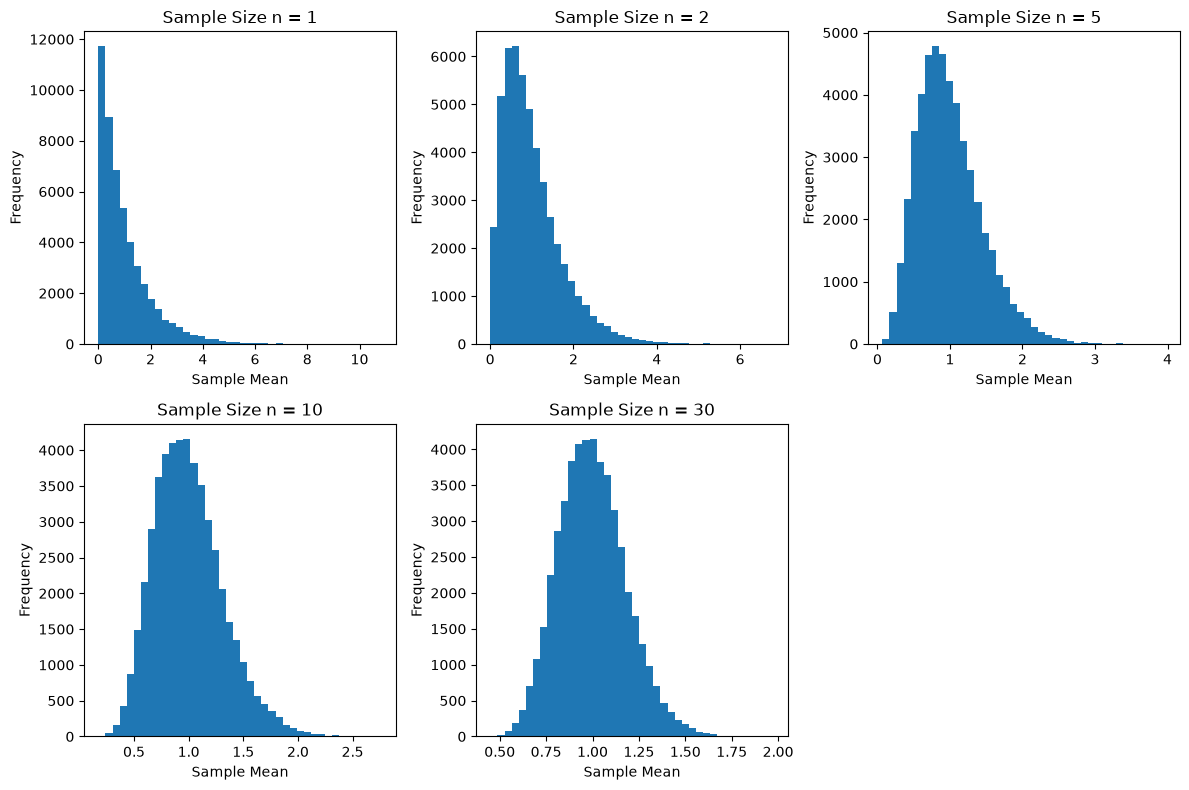

In [95]:
# Create a figure
plt.figure(figsize=(12, 8))

# Plot the distribution of averages for each n
for i, n in enumerate(sample_sizes):
    
    # Create a subplot
    plt.subplot(2, 3, i + 1)
    
    # Plot histogram
    plt.hist(results[n], bins=40)
    
    # Add title
    plt.title("Sample Size n = " + str(n))
    
    # Add x-axis label
    plt.xlabel("Sample Mean")
    
    # Add y-axis label
    plt.ylabel("Frequency")

# Adjust the spacing
plt.tight_layout()

# Show the plots
plt.show()

In [96]:
# Check the theoretical and sample standard deviations
for n in sample_sizes:
    
    # Get the simulated averages
    means = results[n]
    
    # Calculate the sample standard deviation
    sample_sd = means.std()
    
    # Calculate the theoretical standard deviation
    theoretical_sd = 1 / np.sqrt(n)
    
    # Print the results
    print("n =", n)
    print("Sample SD:", sample_sd)
    print("Theoretical SD:", theoretical_sd)
    print()

n = 1
Sample SD: 1.0217369880119938
Theoretical SD: 1.0

n = 2
Sample SD: 0.7125630592507406
Theoretical SD: 0.7071067811865475

n = 5
Sample SD: 0.4473968572597011
Theoretical SD: 0.4472135954999579

n = 10
Sample SD: 0.31587893080330753
Theoretical SD: 0.31622776601683794

n = 30
Sample SD: 0.18239925987508773
Theoretical SD: 0.18257418583505536



In [97]:
# Check the mean of the sample means
for n in sample_sizes:
    
    # Get the sample averages
    means = results[n]
    
    # Calculate their mean
    average = means.mean()
    
    # Print the result
    print("n =", n, "Mean of sample means =", average)

n = 1 Mean of sample means = 1.0170128461378158
n = 2 Mean of sample means = 0.9985190462893118
n = 5 Mean of sample means = 0.9976202097145224
n = 10 Mean of sample means = 1.0002405624901578
n = 30 Mean of sample means = 0.9993394017463377


# Task-4
###  PDF, CDF, and fitting

In [98]:
# Create x values from -4 to 4
x = np.linspace(-4, 4, 200)

# Calculate the PDF of the standard normal distribution
pdf = stats.norm.pdf(x)

# Calculate the CDF of the standard normal distribution
cdf = stats.norm.cdf(x)

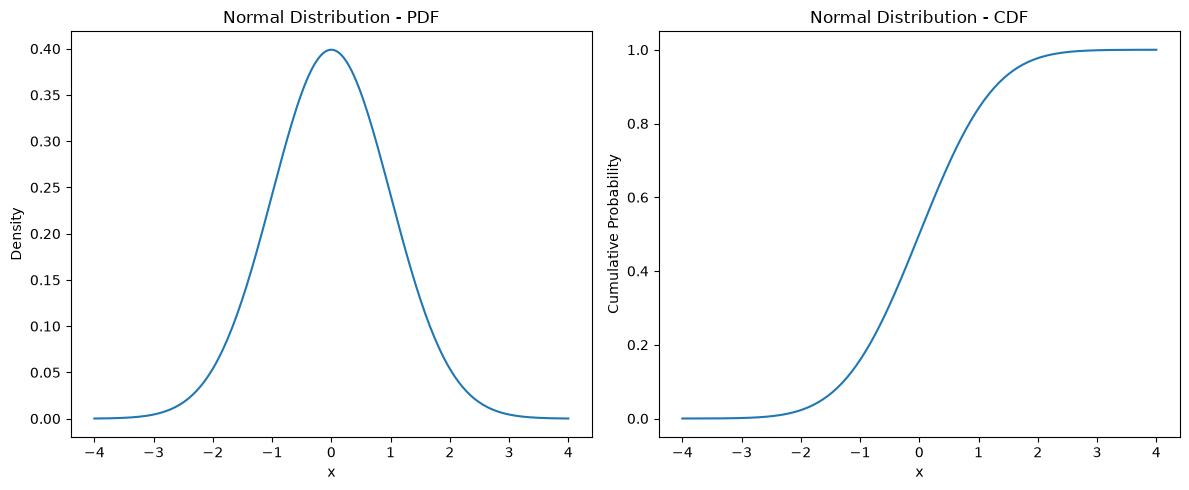

In [99]:
# Create a figure with two plots
plt.figure(figsize=(12, 5))

# First plot: PDF
plt.subplot(1, 2, 1)

# Plot the PDF
plt.plot(x, pdf)

# Add title
plt.title("Normal Distribution - PDF")

# Add x-axis label
plt.xlabel("x")

# Add y-axis label
plt.ylabel("Density")

# Second plot: CDF
plt.subplot(1, 2, 2)

# Plot the CDF
plt.plot(x, cdf)

# Add title
plt.title("Normal Distribution - CDF")

# Add x-axis label
plt.xlabel("x")

# Add y-axis label
plt.ylabel("Cumulative Probability")

# Adjust spacing
plt.tight_layout()

# Show the plots
plt.show()

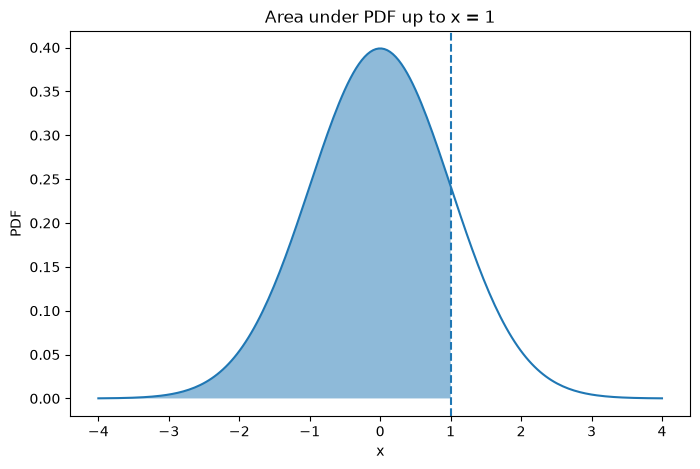

CDF at x = 1: 0.8413447460685429


In [100]:
# Select a value
x_value = 1

# Create x values up to x = 1
x_area = np.linspace(-4, x_value, 200)

# Calculate PDF values
pdf_area = stats.norm.pdf(x_area)

# Calculate the CDF at x = 1
cdf_value = stats.norm.cdf(x_value)

# Plot the PDF
plt.figure(figsize=(8, 5))
plt.plot(x, pdf)

# Shade the area to the left of x = 1
plt.fill_between(x_area, pdf_area, alpha=0.5)

# Draw a vertical line at x = 1
plt.axvline(x_value, linestyle="--")

# Add title
plt.title("Area under PDF up to x = 1")

# Add labels
plt.xlabel("x")
plt.ylabel("PDF")

# Show the plot
plt.show()

# Print the CDF value
print("CDF at x = 1:", cdf_value)

In [101]:
# Probability of a value being below 1
below_1 = stats.norm.cdf(1)

# Probability of a value being below the mean
below_mean = stats.norm.cdf(0)

# Probability of a value being above 1
above_1 = 1 - stats.norm.cdf(1)

# Print the results
print("Fraction below 1:", below_1)
print("Fraction below the mean:", below_mean)
print("Fraction above 1:", above_1)

Fraction below 1: 0.8413447460685429
Fraction below the mean: 0.5
Fraction above 1: 0.15865525393145707


In [102]:
# Find the value at the 90th percentile
p90 = stats.norm.ppf(0.90)

# Print the result
print("90th percentile:", p90)

90th percentile: 1.2815515655446004


In [103]:
# Create x values from 0 to 10
x_exp = np.linspace(0, 10, 200)

# Calculate exponential PDF
pdf_exp = stats.expon.pdf(x_exp, scale=2)

# Calculate exponential CDF
cdf_exp = stats.expon.cdf(x_exp, scale=2)

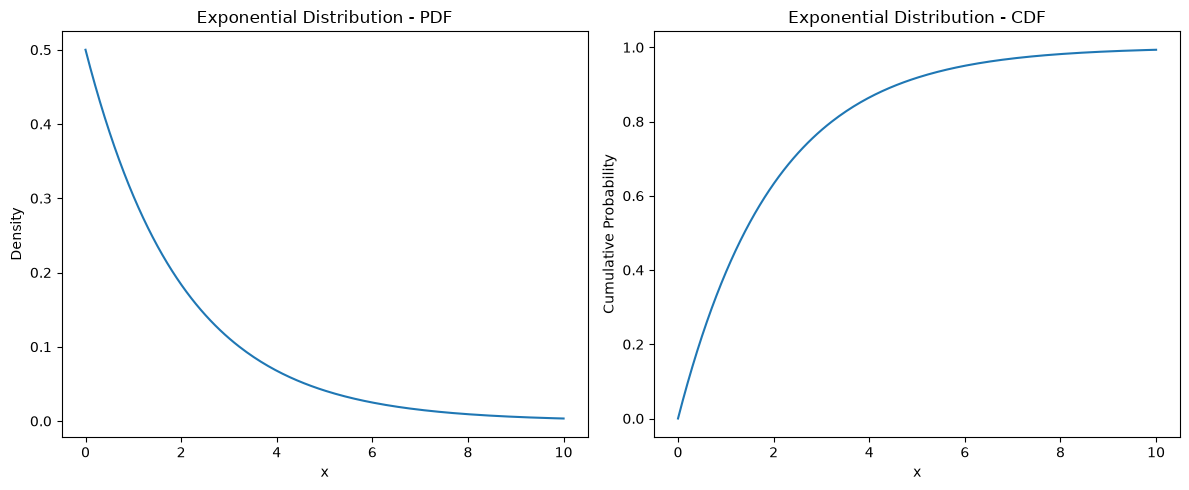

In [104]:
# Create a figure
plt.figure(figsize=(12, 5))

# First plot: Exponential PDF
plt.subplot(1, 2, 1)

# Plot PDF
plt.plot(x_exp, pdf_exp)

# Add title
plt.title("Exponential Distribution - PDF")

# Add labels
plt.xlabel("x")
plt.ylabel("Density")

# Second plot: Exponential CDF
plt.subplot(1, 2, 2)

# Plot CDF
plt.plot(x_exp, cdf_exp)

# Add title
plt.title("Exponential Distribution - CDF")

# Add labels
plt.xlabel("x")
plt.ylabel("Cumulative Probability")

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

# Task-5
### Fit a distribution to real data

In [105]:
# Generate realistic data from an exponential distribution
# We will pretend that we don't know the original distribution
data = rng.exponential(2, 10_000)

# Display the first 10 values
print(data[:10])

[3.46862944 0.66614374 3.88233629 0.08704945 2.14466813 4.89978348
 3.668003   1.47032819 3.37505963 0.45833428]


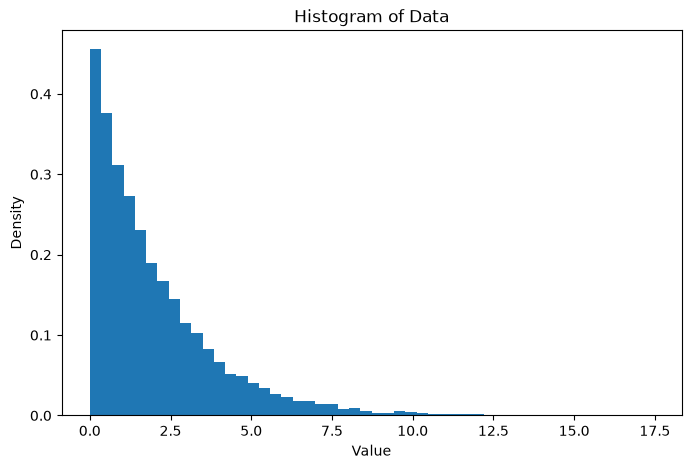

In [106]:
# Plot the histogram of the data
plt.figure(figsize=(8, 5))

# Create histogram
plt.hist(data, bins=50, density=True)

# Add title
plt.title("Histogram of Data")

# Add x-axis label
plt.xlabel("Value")

# Add y-axis label
plt.ylabel("Density")

# Show the plot
plt.show()

In [107]:
# Fit a normal distribution to the data
mu, sigma = stats.norm.fit(data)

# Print fitted parameters
print("Normal distribution")
print("Mean:", mu)
print("Standard deviation:", sigma)

Normal distribution
Mean: 2.014938359213602
Standard deviation: 1.994635677663858


In [108]:
# Fit an exponential distribution to the data
loc, scale = stats.expon.fit(data)

# Print fitted parameters
print("Exponential distribution")
print("Location:", loc)
print("Scale:", scale)

Exponential distribution
Location: 0.00014339694719540534
Scale: 2.0147949622664063


In [109]:
# Create x values for the fitted curves
x_fit = np.linspace(0, data.max(), 500)

# Calculate the fitted normal PDF
normal_pdf = stats.norm.pdf(x_fit, mu, sigma)

# Calculate the fitted exponential PDF
exponential_pdf = stats.expon.pdf(x_fit, loc, scale)

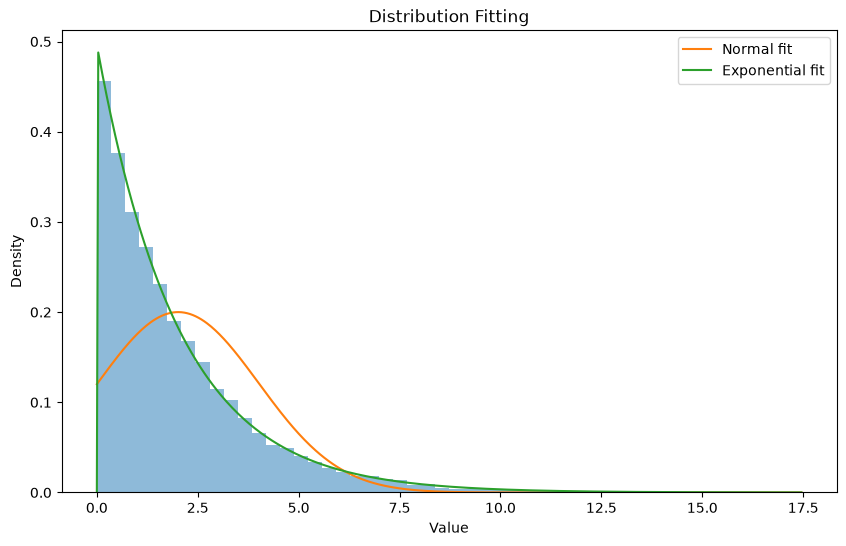

In [110]:
# Plot the histogram
plt.figure(figsize=(10, 6))

plt.hist(data, bins=50, density=True, alpha=0.5)

# Plot fitted normal curve
plt.plot(x_fit, normal_pdf, label="Normal fit")

# Plot fitted exponential curve
plt.plot(x_fit, exponential_pdf, label="Exponential fit")

# Add title
plt.title("Distribution Fitting")

# Add labels
plt.xlabel("Value")
plt.ylabel("Density")

# Show legend
plt.legend()

# Show plot
plt.show()

In [111]:
# Calculate log-likelihood for the normal distribution
ll_norm = np.sum(stats.norm.logpdf(data, mu, sigma))

# Calculate log-likelihood for the exponential distribution
ll_expon = np.sum(stats.expon.logpdf(data, loc, scale))

# Print the log-likelihood values
print("Normal log-likelihood:", ll_norm)
print("Exponential log-likelihood:", ll_expon)

Normal log-likelihood: -21093.99949157503
Exponential log-likelihood: -17005.1743452213


In [112]:
# Compare the two distributions
if ll_norm > ll_expon:
    print("Normal distribution has the higher log-likelihood.")
else:
    print("Exponential distribution has the higher log-likelihood.")

Exponential distribution has the higher log-likelihood.
